In [1]:
import torch
from torch import nn

The output size is
given by the input size $n_h \times n_w$ minus the size of the convolution kernel $k_h \times k_w$ via

$$
(n_h - k_h + 1) \times (n_w - k_w + 1).
$$

where:

- $n_h$: Height of the input
- $n_w$: Width of the input
- $k_h$: Height of the convolution kernel
- $k_w$: Width of the convolution kernel


In [2]:
def corr2d(X, K):
    """Compute 2d correlation"""

    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i : i + h, j : j + w] * K).sum()

    return Y

In [3]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

In [4]:
from typing import Any


class Conv2D(nn.Module):
    def __init__(self, kernel_size, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, X):
        return corr2d(X, self.weight) + self.bias

In [5]:
X = torch.ones((6, 8))
X[:, 2:6] = 0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

A kernel of size $1 \times 2$, such as

$$
K = [1, -1],
$$

computes the difference between two horizontally adjacent pixels:

$$
x_{i,j} - x_{i,j+1}.
$$

As the kernel slides across the image:

- If adjacent pixels are the same, the output is $0$.
- If adjacent pixels are different, the output is nonzero.
- Larger differences produce larger output values.

For example, given the pixel values

$$
[1,\ 1,\ 1,\ 0,\ 0],
$$

the kernel produces

$$
[0,\ 0,\ 1,\ 0].
$$

The nonzero value indicates the location where the pixel intensity changes abruptly, i.e., an **edge**.

This operation is called a **finite difference operator** because it approximates the first derivative of the image in the horizontal direction:

$$
\frac{\partial f(i,j)}{\partial j}
\approx
f(i,j) - f(i,j+1).
$$

Since images are discrete (made of pixels), the derivative is approximated using the difference between neighboring pixel values instead of the continuous derivative.


In [6]:
K = torch.tensor([[1, -1]])
y = corr2d(X, K)
y

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

In [7]:
model = Conv2D((1, 2))
# model.bias.data.zero_()
model.bias.requires_grad_(False)

loss_fn = nn.MSELoss(reduction="sum")

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

for epoch in range(50):
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 4 or epoch == 0:
        print(
            f"Epoch {epoch+1}, "
            f"Loss: {loss.item():.6f}, "
            f"Weight: {model.weight.data}, "
            f"Bias: {model.bias.data}"
        )

Epoch 1, Loss: 17.705309, Weight: tensor([[ 0.4065, -0.0963]]), Bias: tensor([0.])
Epoch 5, Loss: 3.129272, Weight: tensor([[ 0.5550, -0.5471]]), Bias: tensor([0.])
Epoch 10, Loss: 0.869860, Weight: tensor([[ 0.7631, -0.7630]]), Bias: tensor([0.])
Epoch 15, Loss: 0.242257, Weight: tensor([[ 0.8750, -0.8750]]), Bias: tensor([0.])
Epoch 20, Loss: 0.067469, Weight: tensor([[ 0.9340, -0.9340]]), Bias: tensor([0.])
Epoch 25, Loss: 0.018790, Weight: tensor([[ 0.9652, -0.9652]]), Bias: tensor([0.])
Epoch 30, Loss: 0.005233, Weight: tensor([[ 0.9816, -0.9816]]), Bias: tensor([0.])
Epoch 35, Loss: 0.001457, Weight: tensor([[ 0.9903, -0.9903]]), Bias: tensor([0.])
Epoch 40, Loss: 0.000406, Weight: tensor([[ 0.9949, -0.9949]]), Bias: tensor([0.])
Epoch 45, Loss: 0.000113, Weight: tensor([[ 0.9973, -0.9973]]), Bias: tensor([0.])
Epoch 50, Loss: 0.000031, Weight: tensor([[ 0.9986, -0.9986]]), Bias: tensor([0.])


In [8]:
print(f"Trained weight : {model.weight.data}")
model(X)

Trained weight : tensor([[ 0.9986, -0.9986]])


tensor([[ 0.0000,  0.9986,  0.0000,  0.0000,  0.0000, -0.9986,  0.0000],
        [ 0.0000,  0.9986,  0.0000,  0.0000,  0.0000, -0.9986,  0.0000],
        [ 0.0000,  0.9986,  0.0000,  0.0000,  0.0000, -0.9986,  0.0000],
        [ 0.0000,  0.9986,  0.0000,  0.0000,  0.0000, -0.9986,  0.0000],
        [ 0.0000,  0.9986,  0.0000,  0.0000,  0.0000, -0.9986,  0.0000],
        [ 0.0000,  0.9986,  0.0000,  0.0000,  0.0000, -0.9986,  0.0000]],
       grad_fn=<AddBackward0>)

In [9]:
# Construct a two-dimensional convolutional layer with 1 output channel and a
# kernel of shape (1, 2). For the sake of simplicity, we ignore the bias here
conv2d = nn.LazyConv2d(1, kernel_size=(1, 2), bias=False)

# The two-dimensional convolutional layer uses four-dimensional input and
# output in the format of (example, channel, height, width), where the batch
# size (number of examples in the batch) and the number of channels are both 1
X = X.reshape((1, 1, 6, 8))
Y = y.reshape((1, 1, 6, 7))
lr = 3e-2  # Learning rate

for i in range(50):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()
    # Update the kernel
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if i % 5 == 4 or i == 0:
        print(f"epoch {i + 1}, loss {l.sum():.3f}")

epoch 1, loss 25.395
epoch 5, loss 1.234
epoch 10, loss 0.074
epoch 15, loss 0.007
epoch 20, loss 0.001
epoch 25, loss 0.000
epoch 30, loss 0.000
epoch 35, loss 0.000
epoch 40, loss 0.000
epoch 45, loss 0.000
epoch 50, loss 0.000


In [10]:
print(f"Trained weight : {conv2d.weight.data}")
conv2d(X)

Trained weight : tensor([[[[ 1.0000, -1.0000]]]])


tensor([[[[ 7.1526e-06,  1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           -1.0000e+00,  7.1526e-06],
          [ 7.1526e-06,  1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           -1.0000e+00,  7.1526e-06],
          [ 7.1526e-06,  1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           -1.0000e+00,  7.1526e-06],
          [ 7.1526e-06,  1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           -1.0000e+00,  7.1526e-06],
          [ 7.1526e-06,  1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           -1.0000e+00,  7.1526e-06],
          [ 7.1526e-06,  1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           -1.0000e+00,  7.1526e-06]]]], grad_fn=<ConvolutionBackward0>)

In [11]:
torch.eye(10)

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

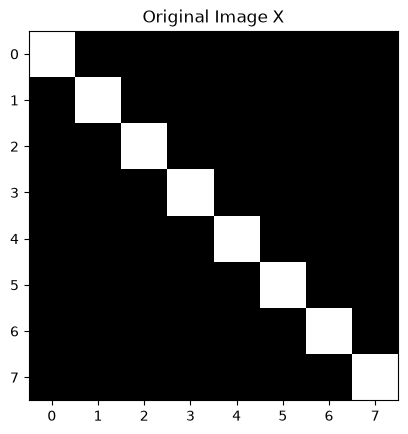

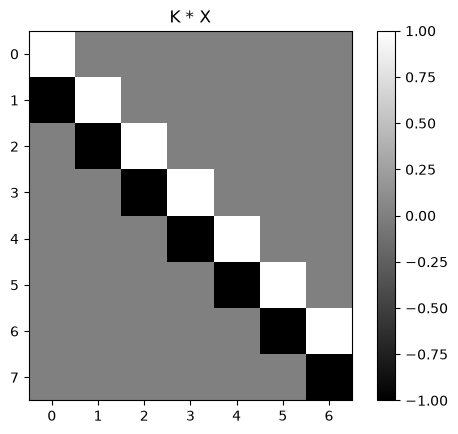

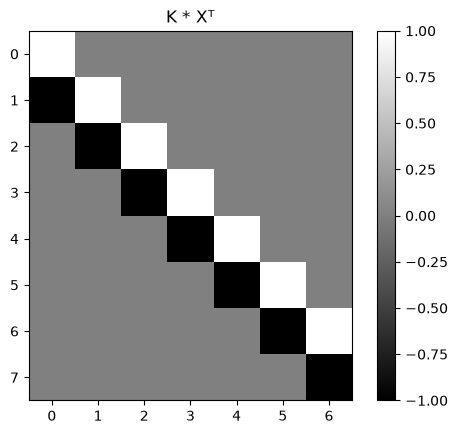

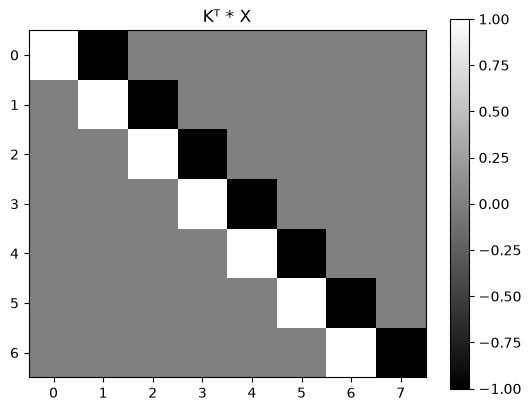

In [12]:
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

# -------------------------------
# Construct image X with a diagonal line
# -------------------------------
X = torch.zeros((8, 8))

for i in range(8):
    X[i, i] = 1

# Display image
plt.imshow(X, cmap="gray")
plt.title("Original Image X")
plt.show()

# -------------------------------
# Kernel
# -------------------------------
K = torch.tensor([[1.0, -1.0]])

# Reshape for conv2d
X_conv = X.unsqueeze(0).unsqueeze(0)  # (1,1,8,8)
K_conv = K.unsqueeze(0).unsqueeze(0)  # (1,1,1,2)

# -------------------------------
# 1. Apply K to X
# -------------------------------
Y = F.conv2d(X_conv, K_conv)

plt.imshow(Y.squeeze(), cmap="gray")
plt.title("K * X")
plt.colorbar()
plt.show()

# -------------------------------
# 2. Transpose X
# -------------------------------
XT = X.T

YT = F.conv2d(XT.unsqueeze(0).unsqueeze(0), K_conv)

plt.imshow(YT.squeeze(), cmap="gray")
plt.title("K * Xᵀ")
plt.colorbar()
plt.show()

# -------------------------------
# 3. Transpose K
# -------------------------------
KT = K.T
KT_conv = KT.unsqueeze(0).unsqueeze(0)

YK = F.conv2d(X_conv, KT_conv)

plt.imshow(YK.squeeze(), cmap="gray")
plt.title("Kᵀ * X")
plt.colorbar()
plt.show()

# Padding


In [13]:
conv2d = nn.LazyConv2d(1, kernel_size=3, padding=1)
X = torch.rand((8, 8))
X = X.reshape((1, 1) + X.shape)
conv2d(X).shape

torch.Size([1, 1, 8, 8])

# Multi input & Multi output channels


In [14]:
def corr2d_multi_in(X, K):
    return sum(corr2d(x, k) for x, k in zip(X, K))


X = torch.tensor(
    [
        [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
        [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]],
    ]
)
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

corr2d_multi_in(X, K)

tensor([[ 56.,  72.],
        [104., 120.]])

In [15]:
def corr2d_multi_in_out(X, K):
    return torch.stack([corr2d_multi_in(X, k) for k in K])


K = torch.stack((K, K + 1, K + 2))
corr2d_multi_in_out(X, K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

In [16]:
X = torch.normal(0, 1, size=(3, 3, 3))
K = torch.normal(0, 1, size=(2, 3, 1, 1))

corr2d_multi_in_out(X, K)

tensor([[[ 1.8608, -2.6921, -4.1057],
         [-0.6630,  1.0255,  1.6357],
         [-2.1774,  0.6715,  0.2816]],

        [[ 1.0680, -4.6531, -3.3416],
         [-0.4906,  0.6121,  1.6542],
         [-2.2174,  0.7514, -0.0204]]])

# Pooling


In [17]:
def pool2d(X, pool_size, mode="max"):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == "max":
                Y[i, j] = X[i : i + p_h, j : j + p_w].max()
            elif mode == "avg":
                Y[i, j] = X[i : i + p_h, j : j + p_w].mean()

    return Y


X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

# LeNet

```text
+-------------------------+
|         FC (10)         |
+-------------------------+
             ^
             |
+-------------------------+
|         FC (84)         |
+-------------------------+
             ^
             |
+-------------------------+
|         FC (120)        |
+-------------------------+
             ^
             |
+-------------------------+
| 2 x 2 AvgPool, stride 2 |
+-------------------------+
             ^
             |
+-------------------------+
|      5 x 5 Conv (16)    |
+-------------------------+
             ^
             |
+-------------------------+
| 2 x 2 AvgPool, stride 2 |
+-------------------------+
             ^
             |
+-------------------------+
| 5 x 5 Conv (6), pad 2   |
+-------------------------+
             ^
             |
+-------------------------+
|     Image (28 x 28)     |
+-------------------------+
```


In [18]:
from typing import Any


def init_cnn(module):
    if isinstance(module, (nn.LazyLinear, nn.LazyConv2d)):
        nn.init.xavier_uniform_(module.weight)


class LeNet(nn.Module):
    def __init__(self, num_classes=10, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.net = nn.Sequential(
            # Block 1
            nn.LazyConv2d(out_channels=6, kernel_size=5, padding=2),
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2),
            # Block 2
            nn.LazyConv2d(out_channels=16, kernel_size=5),
            nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2),
            # Flatten layers to pass on to Dense layers
            nn.Flatten(),
            # Dense Layers
            nn.LazyLinear(120),
            nn.Sigmoid(),
            nn.LazyLinear(84),
            nn.Sigmoid(),
            nn.LazyLinear(num_classes),
        )

    def forward(self, X):
        return self.net(X)

    def layer_summary(self, X_shape):
        X = torch.randn(*X_shape).to("cuda")
        for layer in self.net:
            X = layer(X)
            print(layer.__class__.__name__, "output shape:\t", X.shape)

In [19]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"Device : {device}")

model = LeNet(num_classes=10).to(device)

# # Dummy Input is passed since we are using the lazy layers
# model(torch.randn(1, 1, 28, 28).to(device))

# # Apply your custom Xavier initialization to all layers
# model.apply(init_cnn)

# model.layer_summary((1, 1, 28, 28))

Device : cuda


In [20]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

batch_size = 64
train_dataloader = DataLoader(train_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

In [21]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())


def train(model, dataloader, device, optimizer, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()
        X, y = X.to(device), y.to(device)

        preds = model(X)
        loss = loss_fn(preds, y)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            print(f"Loss : {loss.item():>7f} [{(batch+1)*len(X):>5d} / {size}]")
    if batch % 100 != 0:
        print(f"Loss : {loss.item():>7f} [{(batch+1)*len(X):>5d} / {size:>5d}]")

    return train_loss / num_batches


def test(model, dataloader, device, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accurate = 0, 0
    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            preds = model(X)
            loss = loss_fn(preds, y)

            test_loss += loss.item()
            accurate += (preds.argmax(1) == y).sum().item()
    test_loss /= num_batches
    accurate /= size

    print(
        f"Test Error :\n Avg Loss : {test_loss:>7f} | Accuracy : {100 * accurate:>0.1f}% \n"
    )

    return test_loss, accurate

Epoch 1 
 --------------------------------------------------
Loss : 2.390926 [   64 / 60000]
Loss : 2.290619 [ 6464 / 60000]
Loss : 2.235533 [12864 / 60000]
Loss : 1.421778 [19264 / 60000]
Loss : 0.925616 [25664 / 60000]
Loss : 0.799905 [32064 / 60000]
Loss : 0.645415 [38464 / 60000]
Loss : 0.557696 [44864 / 60000]
Loss : 0.609109 [51264 / 60000]
Loss : 0.417537 [57664 / 60000]
Loss : 0.359634 [30016 / 60000]
Test Error :
 Avg Loss : 0.397548 | Accuracy : 88.2% 

Epoch 2 
 --------------------------------------------------
Loss : 0.402832 [   64 / 60000]
Loss : 0.312352 [ 6464 / 60000]
Loss : 0.288925 [12864 / 60000]
Loss : 0.316370 [19264 / 60000]
Loss : 0.246383 [25664 / 60000]
Loss : 0.379933 [32064 / 60000]
Loss : 0.192042 [38464 / 60000]
Loss : 0.307756 [44864 / 60000]
Loss : 0.326197 [51264 / 60000]
Loss : 0.284651 [57664 / 60000]
Loss : 0.098761 [30016 / 60000]
Test Error :
 Avg Loss : 0.225809 | Accuracy : 92.9% 

Epoch 3 
 --------------------------------------------------
Los

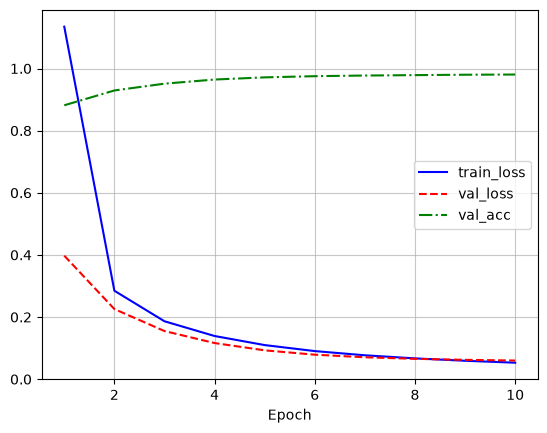

In [22]:
import matplotlib.pyplot as plt

history = {"train_loss": [], "val_loss": [], "val_acc": []}

epochs = 10

for epoch in range(epochs):
    print(f"Epoch {epoch + 1} \n --------------------------------------------------")
    train_loss = train(model, train_dataloader, device, optimizer, loss_fn)
    val_loss, val_acc = test(model, test_dataloader, device, loss_fn)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

epochs_range = range(1, epochs + 1)
plt.plot(epochs_range, history["train_loss"], color="blue", label="train_loss")
plt.plot(
    epochs_range, history["val_loss"], color="red", linestyle="--", label="val_loss"
)
plt.plot(
    epochs_range, history["val_acc"], color="green", linestyle="-.", label="val_acc"
)
plt.xlabel("Epoch")
plt.legend()
plt.grid(True, alpha=0.7)
plt.show()

# AlexNet


In [29]:
from typing import Any

import torch
from torch import nn


class AlexNet(nn.Module):
    def __init__(self, num_classes, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.net = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Block 2
            nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Block 3
            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Flatten layer
            nn.Flatten(),
            # Block 4
            nn.LazyLinear(out_features=4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            # Block 5
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            # Output
            nn.Linear(in_features=4096, out_features=num_classes),
        )

    def forward(self, X):
        return self.net(X)

In [30]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

alexnet_transforms = v2.Compose(
    [
        v2.Lambda(lambda img: img.convert("RGB")),
        v2.ToImage(),
        v2.Resize((224, 224)),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

train_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=alexnet_transforms
)
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=alexnet_transforms
)

batch_size = 64
train_dataloader = DataLoader(train_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

In [31]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

model = AlexNet(num_classes=10).to(device)

print(f"Device : {device}")
model

Device : cuda


AlexNet(
  (net): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): LazyLinear(in_features=0, out_features=4096, bias=True)
    (15): ReLU()
    (16): Dropout(p=0.5, inplace=False)
    (17): Linear(in_features=4096, out_features=4096, bias=True)
    (18): ReLU()
    (19): Dropout(p=

In [32]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())


def train(model, dataloader, device, optimizer, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()

        X, y = X.to(device), y.to(device)

        preds = model(X)
        loss = loss_fn(preds, y)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if batch % 200 == 0:
            print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")
    if batch % 200 != 0:
        print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")

    return train_loss / num_batches


def test(model, dataloader, device, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accurate = 0, 0

    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            preds = model(X)
            loss = loss_fn(preds, y)

            test_loss += loss.item()
            accurate += (preds.argmax(1) == y).sum().item()

    test_loss /= num_batches
    accurate /= size

    print(
        f"Test Error :\n Avg Loss : {test_loss:>7f} | Accuracy : {100 * accurate:>0.1f}% \n"
    )

    return test_loss, accurate

Epoch 1
-------------------------------------------
Loss : 2.303123 [  64 / 60000]
Loss : 0.374060 [12864 / 60000]
Loss : 0.478715 [25664 / 60000]
Loss : 0.428380 [38464 / 60000]
Loss : 0.353233 [51264 / 60000]
Loss : 0.366245 [30016 / 60000]
Test Error :
 Avg Loss : 0.389935 | Accuracy : 85.3% 

Epoch 2
-------------------------------------------
Loss : 0.343879 [  64 / 60000]
Loss : 0.249756 [12864 / 60000]
Loss : 0.315417 [25664 / 60000]
Loss : 0.251035 [38464 / 60000]
Loss : 0.279929 [51264 / 60000]
Loss : 0.367797 [30016 / 60000]
Test Error :
 Avg Loss : 0.364638 | Accuracy : 86.5% 

Epoch 3
-------------------------------------------
Loss : 0.293051 [  64 / 60000]
Loss : 0.167076 [12864 / 60000]
Loss : 0.397380 [25664 / 60000]
Loss : 0.226830 [38464 / 60000]
Loss : 0.287896 [51264 / 60000]
Loss : 0.373604 [30016 / 60000]
Test Error :
 Avg Loss : 0.349530 | Accuracy : 87.3% 

Epoch 4
-------------------------------------------
Loss : 0.278464 [  64 / 60000]
Loss : 0.238165 [12864 

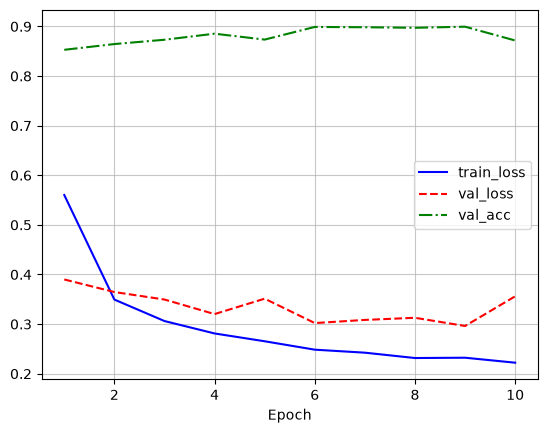

In [33]:
history = {"train_loss": [], "val_acc": [], "val_loss": []}

epochs = 10

for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------------------")
    train_loss = train(model, train_dataloader, device, optimizer, loss_fn)
    val_loss, val_acc = test(model, test_dataloader, device, loss_fn)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)


def plot_cnn(history_dict):
    epochs_range = range(1, len(history_dict["train_loss"]) + 1)
    plt.plot(epochs_range, history_dict["train_loss"], color="blue", label="train_loss")
    plt.plot(
        epochs_range,
        history_dict["val_loss"],
        color="red",
        linestyle="--",
        label="val_loss",
    )
    plt.plot(
        epochs_range,
        history_dict["val_acc"],
        color="green",
        linestyle="-.",
        label="val_acc",
    )
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.show()


plot_cnn(history)

# VGG


In [ ]:
from typing import Any

import torch
from torch import nn


class VGGNet(nn.Module):
    def __init__(self, num_classes, arch, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.arch = arch
        conv_blks = []
        for num_convs, out_channels in arch:
            conv_blks.append(self.vgg_block(num_convs, out_channels))

        self.net = nn.Sequential(
            # Convolutional Blocks
            *conv_blks,
            # Flatten
            nn.Flatten(),
            # Fully connected layers
            nn.LazyLinear(4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(num_classes)
        )

    def vgg_block(self, num_convs, out_channels):
        layers = []
        for _ in range(num_convs):
            layers.append(nn.LazyConv2d(out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        return nn.Sequential(*layers)

    def forward(self, X):
        return self.net(X)

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

vgg_transform = v2.Compose(
    [v2.ToImage(), v2.Resize((224, 224)), v2.ToDtype(torch.float32, scale=True)]
)

train_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=vgg_transform
)
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=vgg_transform
)

batch_size = 64
train_dataloader = DataLoader(train_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

In [ ]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

model = VGGNet(num_classes=10, arch=arch).to(device)

In [37]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

history = {"train_loss": [], "val_loss": [], "val_acc": []}

epochs = 10

for epoch in range(epochs):
    print(f"Epoch : {epoch + 1}\n--------------------------")
    train_loss = train(model, train_dataloader, device, optimizer, loss_fn)
    val_loss, val_acc = test(model, test_dataloader, device, loss_fn)

    history["train_loss"].append(train_loss)
    history["val_acc"].append(val_acc)
    history["val_loss"].append(val_loss)

plot_cnn(history)

Epoch : 1
--------------------------
Loss : 2.301495 [  64 / 60000]
Loss : 0.393363 [12864 / 60000]
Loss : 0.520794 [25664 / 60000]
Loss : 0.327655 [38464 / 60000]
Loss : 0.425592 [51264 / 60000]
Loss : 0.308966 [30016 / 60000]
Test Error :
 Avg Loss : 0.390517 | Accuracy : 85.1% 

Epoch : 2
--------------------------
Loss : 0.241219 [  64 / 60000]
Loss : 0.150609 [12864 / 60000]
Loss : 0.289026 [25664 / 60000]
Loss : 0.227379 [38464 / 60000]
Loss : 0.284296 [51264 / 60000]
Loss : 0.288056 [30016 / 60000]
Test Error :
 Avg Loss : 0.297328 | Accuracy : 88.9% 

Epoch : 3
--------------------------
Loss : 0.199748 [  64 / 60000]
Loss : 0.153110 [12864 / 60000]
Loss : 0.286016 [25664 / 60000]
Loss : 0.164659 [38464 / 60000]
Loss : 0.238007 [51264 / 60000]
Loss : 0.179333 [30016 / 60000]
Test Error :
 Avg Loss : 0.282289 | Accuracy : 89.9% 

Epoch : 4
--------------------------
Loss : 0.231043 [  64 / 60000]
Loss : 0.135061 [12864 / 60000]


KeyboardInterrupt: 

In [ ]:
arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

checkpoint = {
    "arch": arch,
    "epoch": epoch + 1,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": train_loss,
}

torch.save(checkpoint, "models/vgg_chkpoint1.pth")

# Google Net


```
GoogLeNet
─────────

Input
  │
7×7 Conv
  │
3×3 MaxPool
  │
1×1 Conv
  │
3×3 Conv
  │
3×3 MaxPool
  │
Inception ×2
  │
3×3 MaxPool
  │
Inception ×5
  │
3×3 MaxPool
  │
Inception ×2
  │
Global AvgPool
  │
Fully Connected
```

```
                    Inception Module

                       Concatenate
                 ┌────────┬────────┬────────┬────────┐
                 ▲        ▲        ▲        ▲
              1×1 Conv  3×3 Conv  5×5 Conv 1×1 Conv
                 ▲        ▲        ▲        ▲
                 │     1×1 Conv 1×1 Conv 3×3 MaxPool
                 │        ▲        ▲        ▲
                 └────────┴────────┴────────┘
                          Input
```


In [2]:
import torch
from torch import nn
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

In [ ]:
from typing import Any


class Inception(nn.Module):
    def __init__(self, c1, c2, c3, c4, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.branch1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.ReLU())
        self.branch2 = nn.Sequential(
            nn.LazyConv2d(c2[0], kernel_size=1),
            nn.ReLU(),
            nn.LazyConv2d(c2[1], kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.branch3 = nn.Sequential(
            nn.LazyConv2d(c3[0], kernel_size=1),
            nn.ReLU(),
            nn.LazyConv2d(c3[1], kernel_size=5, padding=2),
            nn.ReLU(),
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, padding=1),
            nn.LazyConv2d(c4, kernel_size=1),
            nn.ReLU(),
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat((b1, b2, b3, b4), dim=1)

# ResNet


In [ ]:
import torch
from torch import nn
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torch.nn import functional as F

In [ ]:
class Residual(nn.Module):
    def __init__(self, channels, use_1x1=False, stride=1):
        super().__init__()

        self.main = nn.Sequential(
            nn.LazyConv2d(channels, 3, padding=1, stride=stride),
            nn.LazyBatchNorm2d(),
            nn.ReLU(),
            nn.LazyConv2d(channels, 3, padding=1),
            nn.LazyBatchNorm2d(),
        )

        if use_1x1:
            self.shortcut = nn.Sequential(nn.LazyConv2d(channels, 1, stride=stride))
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        y = self.main(x)
        shortcut = self.shortcut(x)
        return F.relu(y + shortcut)

# Fine Tuning


In [38]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torchvision
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt

In [39]:
train_data = ImageFolder(
    r"C:\Users\USER\ipnyb files\DL\data\hotdog-nothotdog\train",
    transform=v2.Compose(
        [
            v2.RandomResizedCrop(224),
            v2.RandomHorizontalFlip(),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    ),
)
test_data = ImageFolder(
    r"C:\Users\USER\ipnyb files\DL\data\hotdog-nothotdog\test",
    transform=v2.Compose(
        [
            v2.Resize(256),
            v2.CenterCrop(224),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    ),
)

batch_size = 64
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

In [7]:
def train(model, dataloader, device, optimizer, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()

        X, y = X.to(device), y.to(device)

        preds = model(X)
        loss = loss_fn(preds, y)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if batch % 200 == 0:
            print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")
    if batch % 200 != 0:
        print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")

    return train_loss / num_batches


def test(model, dataloader, device, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accurate = 0, 0

    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            preds = model(X)
            loss = loss_fn(preds, y)

            test_loss += loss.item()
            accurate += (preds.argmax(1) == y).sum().item()

    test_loss /= num_batches
    accurate /= size

    print(
        f"Test Error :\n Avg Loss : {test_loss:>7f} | Accuracy : {100 * accurate:>0.1f}% \n"
    )

    return test_loss, accurate


def plot_cnn(history_dict):
    epochs_range = range(1, len(history_dict["train_loss"]) + 1)
    plt.plot(epochs_range, history_dict["train_loss"], color="blue", label="train_loss")
    plt.plot(
        epochs_range,
        history_dict["val_loss"],
        color="red",
        linestyle="--",
        label="val_loss",
    )
    plt.plot(
        epochs_range,
        history_dict["val_acc"],
        color="green",
        linestyle="-.",
        label="val_acc",
    )
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.show()

In [41]:
pretrained_net = resnet18(weights=ResNet18_Weights.DEFAULT)
pretrained_net.fc

Linear(in_features=512, out_features=1000, bias=True)

In [ ]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)

lr = 1e-4

params_1x = [
    param
    for name, param in model.named_parameters()
    if name not in ("fc.weight", "fc.bias")
]

optimizer = torch.optim.Adam(
    [{"params": params_1x}, {"params": model.fc.parameters(), "lr": lr * 10}], lr=lr
)

loss_fn = nn.CrossEntropyLoss()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

Epoch 1
----------------------
Loss : 0.693849 [  64 / 4242]
Loss : 0.176553 [1206 / 4242]
Test Error :
 Avg Loss : 0.270615 | Accuracy : 89.2% 

Epoch 2
----------------------
Loss : 0.237392 [  64 / 4242]
Loss : 0.221602 [1206 / 4242]
Test Error :
 Avg Loss : 0.269791 | Accuracy : 90.0% 

Epoch 3
----------------------
Loss : 0.348750 [  64 / 4242]
Loss : 0.331084 [1206 / 4242]
Test Error :
 Avg Loss : 0.252165 | Accuracy : 90.5% 

Epoch 4
----------------------
Loss : 0.137533 [  64 / 4242]
Loss : 0.200386 [1206 / 4242]
Test Error :
 Avg Loss : 0.293557 | Accuracy : 90.2% 

Epoch 5
----------------------
Loss : 0.139549 [  64 / 4242]
Loss : 0.222912 [1206 / 4242]
Test Error :
 Avg Loss : 0.278558 | Accuracy : 89.8% 

Epoch 6
----------------------
Loss : 0.093126 [  64 / 4242]
Loss : 0.173826 [1206 / 4242]
Test Error :
 Avg Loss : 0.305888 | Accuracy : 89.0% 

Epoch 7
----------------------
Loss : 0.212705 [  64 / 4242]
Loss : 0.313503 [1206 / 4242]
Test Error :
 Avg Loss : 0.327616

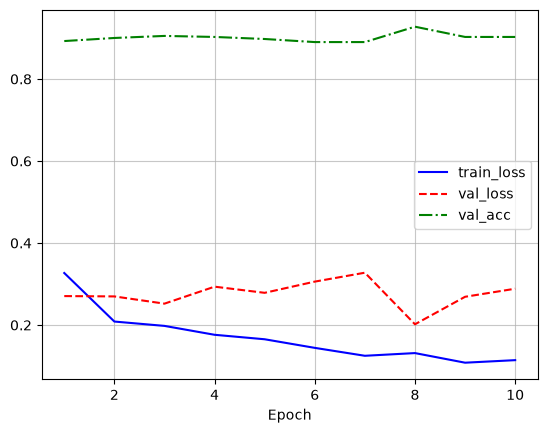

In [43]:
history = {"train_loss": [], "val_acc": [], "val_loss": []}

epochs = 10

for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n----------------------")
    train_loss = train(model, train_dataloader, device, optimizer, loss_fn)
    val_loss, val_acc = test(model, test_dataloader, device, loss_fn)

    history["train_loss"].append(train_loss)
    history["val_acc"].append(val_acc)
    history["val_loss"].append(val_loss)

plot_cnn(history)

# Review


In [8]:
import torch
from torch import nn
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import FashionMNIST
from torchvision.transforms import v2
from torch.utils.data import DataLoader

In [9]:
pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)
pretrained.fc

Linear(in_features=512, out_features=1000, bias=True)

In [10]:
train_data = FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose(
        [
            v2.Lambda(lambda img: img.convert("RGB")),
            v2.ToImage(),
            v2.Resize((224, 224)),
            v2.ToDtype(torch.float32, scale=True),
        ]
    ),
)
test_data = FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose(
        [
            v2.Lambda(lambda img : img.convert("RGB")),
            v2.ToImage(),
            v2.Resize((224, 224)),
            v2.ToDtype(torch.float32, scale=True),
        ]
    ),
)

train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64)

In [11]:
def train(model, dataloader, device, optimizer, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()

        X, y = X.to(device), y.to(device)

        preds = model(X)
        loss = loss_fn(preds, y)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if batch % 200 == 0:
            print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")
    if batch % 200 != 0:
        print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")

    return train_loss / num_batches


def test(model, dataloader, device, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accurate = 0, 0

    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            preds = model(X)
            loss = loss_fn(preds, y)

            test_loss += loss.item()
            accurate += (preds.argmax(1) == y).sum().item()

    test_loss /= num_batches
    accurate /= size

    print(
        f"Test Error :\n Avg Loss : {test_loss:>7f} | Accuracy : {100 * accurate:>0.1f}% \n"
    )

    return test_loss, accurate


def plot_cnn(history_dict):
    epochs_range = range(1, len(history_dict["train_loss"]) + 1)
    plt.plot(epochs_range, history_dict["train_loss"], color="blue", label="train_loss")
    plt.plot(
        epochs_range,
        history_dict["val_loss"],
        color="red",
        linestyle="--",
        label="val_loss",
    )
    plt.plot(
        epochs_range,
        history_dict["val_acc"],
        color="green",
        linestyle="-.",
        label="val_acc",
    )
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.show()

In [12]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.to("cuda")
model.fc = nn.Linear(model.fc.in_features, 10).to("cuda")

In [13]:
loss_fn = nn.CrossEntropyLoss()


params_1x = [
    param
    for name, param in model.named_parameters()
    if name not in ("fc.weight", "fc.bias")
]

optimizer = torch.optim.Adam(
    [{"params": params_1x}, {"params": model.fc.parameters(), "lr": 0.001}], lr=0.01
)

In [14]:
epochs = 3
for epoch in range(epochs):
    print(f"Epoch : {epoch+1}---------------------------------------")
    train_loss = train(model, train_dataloader, "cuda", optimizer, loss_fn)
    val_loss, val_acc = test(model, train_dataloader, "cuda", loss_fn)

Epoch : 1---------------------------------------
Loss : 2.448339 [  64 / 60000]
Loss : 0.424021 [12864 / 60000]
Loss : 0.488563 [25664 / 60000]
Loss : 0.321865 [38464 / 60000]
Loss : 0.224941 [51264 / 60000]
Loss : 0.226194 [30016 / 60000]
Test Error :
 Avg Loss : 1.126853 | Accuracy : 62.5% 

Epoch : 2---------------------------------------
Loss : 0.363814 [  64 / 60000]
Loss : 0.232600 [12864 / 60000]
Loss : 0.159696 [25664 / 60000]
Loss : 0.307158 [38464 / 60000]
Loss : 0.125340 [51264 / 60000]
Loss : 0.155680 [30016 / 60000]
Test Error :
 Avg Loss : 0.251557 | Accuracy : 91.0% 

Epoch : 3---------------------------------------
Loss : 0.153464 [  64 / 60000]
Loss : 0.248058 [12864 / 60000]
Loss : 0.095728 [25664 / 60000]
Loss : 0.420008 [38464 / 60000]
Loss : 0.133301 [51264 / 60000]
Loss : 0.082407 [30016 / 60000]
Test Error :
 Avg Loss : 0.210402 | Accuracy : 92.2% 

